# Lab 18: Fast-Food Drive-Thru Model

**Problem Statement:**
Simulate a drive-thru process (order, pay, pick up) to identify the system's operational bottlenecks.


### Theory and Approach

This represents a **Tandem Queue System** (series of queues).
The Drive-Thru consists of three sequential stages:
1. **Order Station**: Customer places their order.
2. **Pay Station**: Customer pays for the order.
3. **Pickup Station**: Customer receives their food.

Each station acts as a single-server queue. A customer must complete service at stage $i$ before moving to stage $i+1$. 
- **Bottleneck**: The station with the highest utilization and longest average queue is the bottleneck of the system.

We will simulate this flow using **SimPy** (a process-based discrete-event simulation framework in Python) which makes modeling tandem queues very straightforward, or we can use custom DES logic. Here, we'll use a custom DES logic tracking events across multiple stations.


--- Station Performance Metrics ---
   Order Station: Avg Wait = 1.03 mins, Utilization = 34.8%
     Pay Station: Avg Wait = 1.56 mins, Utilization = 43.2%
  Pickup Station: Avg Wait = 51.78 mins, Utilization = 94.2%

Bottleneck Identified: The station with the highest utilization and waiting time.


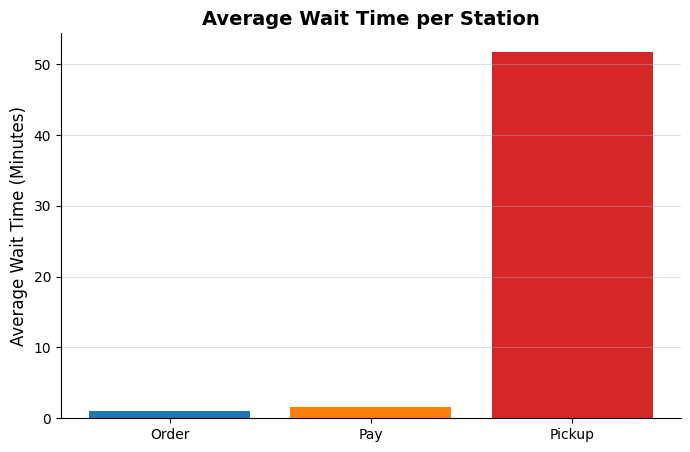

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

SIM_CUSTOMERS = 100

MEAN_INTERARRIVAL = 2.0  # Arrive every 2 mins

# Mean service times at each station
ST_ORDER = 1.0 
ST_PAY = 1.5
ST_PICKUP = 3.0 # Pickup takes the longest!

class Station:
    def __init__(self, name, mean_service_time):
        self.name = name
        self.mean_st = mean_service_time
        self.available_time = 0.0 # Time when the server will be free next
        self.utilization_time = 0.0
        self.total_wait = 0.0

stations = [
    Station("Order", ST_ORDER),
    Station("Pay", ST_PAY),
    Station("Pickup", ST_PICKUP)
]

arrival_times = []
current_time = 0.0

for _ in range(SIM_CUSTOMERS):
    current_time += np.random.exponential(MEAN_INTERARRIVAL)
    arrival_times.append(current_time)

# Track when each customer finishes each stage
customer_journey = []

for cust_id, arrival in enumerate(arrival_times):
    cust_data = {'ID': cust_id, 'Arrival': arrival}
    
    current_cust_time = arrival
    
    for station in stations:
        # Start service is the max of (when customer arrives at station, when station is free)
        start_service = max(current_cust_time, station.available_time)
        wait_time = start_service - current_cust_time
        station.total_wait += wait_time
        
        # Perform service
        service_duration = np.random.exponential(station.mean_st)
        end_service = start_service + service_duration
        
        # Update station stats
        station.available_time = end_service
        station.utilization_time += service_duration
        
        # Record data
        cust_data[f'{station.name}_Wait'] = wait_time
        cust_data[f'{station.name}_End'] = end_service
        current_cust_time = end_service
        
    customer_journey.append(cust_data)
    
df_journey = pd.DataFrame(customer_journey)
total_sim_time = stations[-1].available_time

print("--- Station Performance Metrics ---")
for station in stations:
    avg_wait = station.total_wait / SIM_CUSTOMERS
    utilization = (station.utilization_time / total_sim_time) * 100
    print(f"{station.name:>8} Station: Avg Wait = {avg_wait:.2f} mins, Utilization = {utilization:.1f}%")

print("\nBottleneck Identified: The station with the highest utilization and waiting time.")
avg_waits = [df_journey[f'{s.name}_Wait'].mean() for s in stations]

plt.figure(figsize=(8, 5))
plt.bar([s.name for s in stations], avg_waits, color=['#1f77b4', '#ff7f0e', '#d62728'])
plt.title("Average Wait Time per Station", fontsize=14, fontweight='bold')
plt.ylabel("Average Wait Time (Minutes)", fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()
